# Module 5 Lab 1: Chart It, Then Test It


In [1]:
import pandas as pd
import seaborn as sns
import scipy
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("chickwts.csv")

In [3]:
df.groupby("feed")["weight"].mean().sort_values()

feed
horsebean    160.200000
linseed      218.750000
soybean      246.428571
meatmeal     276.909091
casein       323.583333
sunflower    328.916667
Name: weight, dtype: float64

In [4]:
feed_order = df.groupby("feed")["weight"].mean().sort_values().index

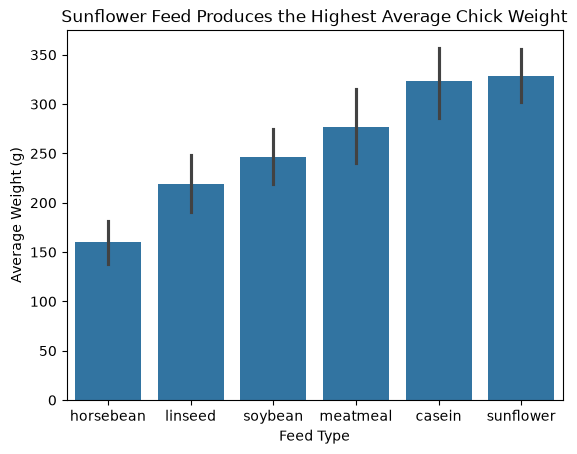

In [5]:
sns.barplot(data=df, x="feed", y="weight", order=feed_order)
plt.title("Sunflower Feed Produces the Highest Average Chick Weight")
plt.xlabel("Feed Type")
plt.ylabel("Average Weight (g)")
plt.show()

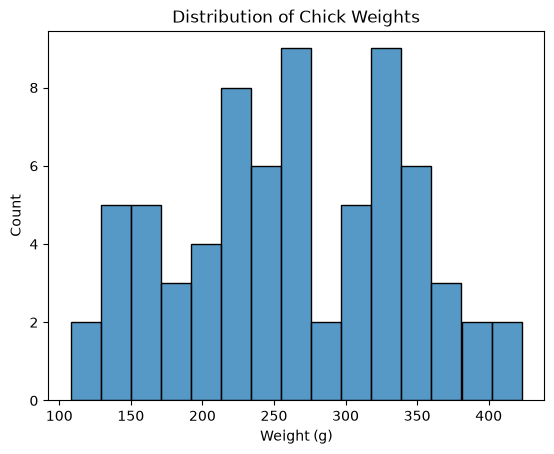

In [6]:
sns.histplot(data=df, x="weight", bins=15)
plt.title("Distribution of Chick Weights")
plt.xlabel("Weight (g)")
plt.ylabel("Count")
plt.show()

In [7]:
museum = pd.read_csv("museum_visitors.csv")

In [8]:
museum["Date"] = pd.to_datetime(museum["Date"])

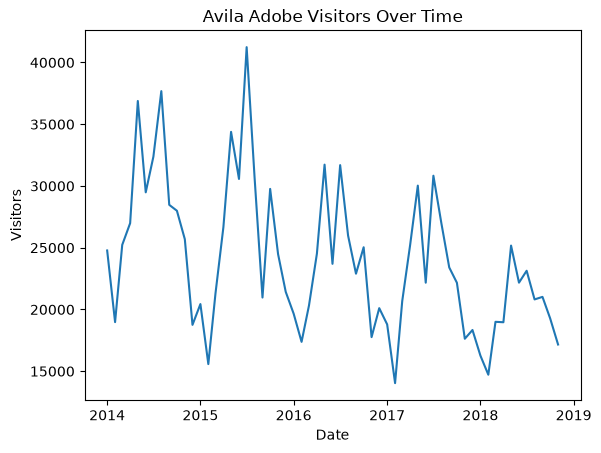

In [9]:
sns.lineplot(data=museum, x="Date", y="Avila Adobe")
plt.title("Avila Adobe Visitors Over Time")
plt.xlabel("Date")
plt.ylabel("Visitors")
plt.show()

From 2014 to 2018, Avila Adobe visitor counts fluctuate throughout each year, reaching a maximum of above 40,000 in July 2015, followed by a general decreasing trend, with about 23,000 visitors in July 2018.

In [10]:
museum["Total Visitors"] = (
    museum["Avila Adobe"]
    + museum["Firehouse Museum"]
    + museum["Chinese American Museum"]
    + museum["America Tropical Interpretive Center"]
)

In [11]:
museum["Date"] = pd.to_datetime(museum["Date"])

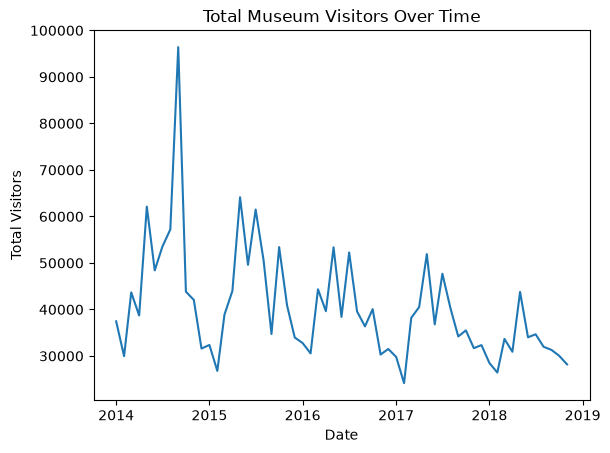

In [12]:
sns.lineplot(data=museum, x="Date", y="Total Visitors")
plt.title("Total Museum Visitors Over Time")
plt.xlabel("Date")
plt.ylabel("Total Visitors")
plt.show()

In [13]:
museum.loc[museum["Total Visitors"].idxmax(), ["Date", "Total Visitors"]]

Date              2014-09-01 00:00:00
Total Visitors                  96399
Name: 8, dtype: object

Data for all museum visitors over the same period confirm the overall trend. After reaching a maximum of above 96,000 visitors in September 2014, attendance generally declines from year to year.



In [14]:
sales = pd.read_csv("sales_clean.csv")


In [15]:
sales.columns

Index(['order_id', 'date', 'product', 'price', 'qty', 'zip'], dtype='str')

In [16]:
sales["revenue"] = sales["price"] * sales["qty"]

In [17]:
sales[["price", "qty", "revenue"]].head()

,price,qty,revenue
0,11.36,4,45.44
1,14.79,3,44.37
2,5.50,1,5.50
3,37.53,1,37.53
4,45.59,4,182.36


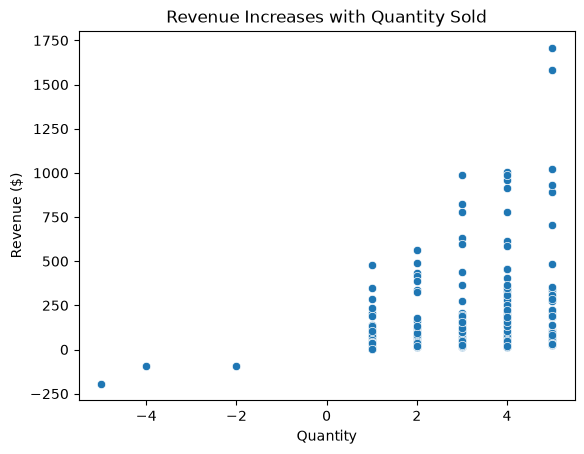

In [18]:
sns.scatterplot(data=sales, x="qty", y="revenue")
plt.title("Revenue Increases with Quantity Sold")
plt.xlabel("Quantity")
plt.ylabel("Revenue ($)")
plt.show()

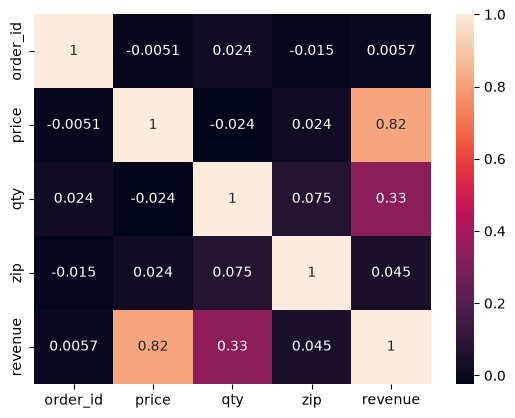

In [19]:
sns.heatmap(sales.corr(numeric_only=True), annot=True)
plt.show()

The strongest off-diagonal strong positive correlation is between price and revenue (r = 0.82).


In [20]:
sales[sales["qty"] < 0]

,order_id,date,product,price,qty,zip,revenue
199,1140,2026-04-18,webcam,38.69,-5,98101,-193.45
255,1233,2026-05-09,desk lamp,22.64,-4,10001,-90.56
289,1025,2026-04-27,keyboard,47.30,-2,2116,-94.60


### Null Hypothesis
There is no difference in mean weight between sunflower-fed and horsebean-fed chicks.

In [21]:
sunflower = df[df["feed"] == "sunflower"]["weight"]
horsebean = df[df["feed"] == "horsebean"]["weight"]

In [22]:
from scipy.stats import ttest_ind

ttest_ind(sunflower, horsebean, equal_var=False)

TtestResult(statistic=np.float64(9.044878424622727), pvalue=np.float64(1.6903886311534453e-08), df=np.float64(19.963715769943583))

In [23]:
round(sunflower.mean() - horsebean.mean(), 2)

np.float64(168.72)

### Conclusion
Sunflower-fed chicks had a mean weight 168.72 g higher than horsebean-fed chicks, with p < 0.001. As a result, we reject the null hypothesis and accept the alternative hypothesis: the sunflower mean is higher, and the observed difference is statistically significant.

### Honest-Chart Audit

For the bar chart, I used a zero baseline and labeled the y-axis in grams so the differences in mean chick weight between feed types are clear and not misleading.